In [1]:
%pwd

'/home/tzuhsuan/GitHub/QFoam/High-fidelity-Rydberg-control-Z-gates-with-time-optimal-pulses/Manuscript-figures'

In [2]:
import os
import glob
import time
from IPython.display import clear_output

from qutip import *
import math

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

from rdquantum.pulse_shape import Saffman_shape
from rdquantum.fidelity import fidelity
from rdquantum.optimizer.de import de

# plt.rcParams["figure.figsize"] = [8, 5]
plt.rcParams["figure.figsize"] = [8, 3]
plt.rcParams["figure.autolayout"] = True
plt.rcParams["axes.edgecolor"] = "black"
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.linewidth"] = 2.50
plt.figure(dpi=1200)

<Figure size 9600x3600 with 0 Axes>

<Figure size 9600x3600 with 0 Axes>

In [11]:
# Gaussian500_53S_5L_BrrX
brr = [10, 50, 75, 100, 125, 150, 200, 250, 300, 400, 500]
# brr = [10, 50, 75, 100, 125, 150, 200, 250, 300, 400, 500, 750, 1000, 1250, 1500]

brr_op_fidelity = []
brr_op_fidelity_r2 = []
brr_op_tgate = []
root_dir = "Gaussian500_53S_5L_BrrX"
data_dir_prefix = "Gaussian500_53S_5L_Brr"
for i in range(len(brr)):
    opinfo_file = "../{}/{}{}/out.npz".format(root_dir, data_dir_prefix, brr[i])
    # opinfo_r2_file = "../{}/{}{}/out_r2.npz".format(root_dir, data_dir_prefix, brr[i])
    oppulse_file = "../{}/{}{}/out-op_pulse.npz".format(root_dir, data_dir_prefix, brr[i])
    opinfo = np.load(opinfo_file, allow_pickle=True)
    # opinfo_r2 = np.load(opinfo_r2_file, allow_pickle=True)
    oppulse = np.load(oppulse_file, allow_pickle=True)
    
    brr_op_fidelity.append(1-opinfo["op_fidelity"].item(0))
    # brr_op_fidelity_r2.append(1-opinfo_r2["op_fidelity"].item(0))
    brr_op_tgate.append(oppulse['T_gate'].item(0))
    
# Gaussian500_DeltaX
deltaamp = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
delta_op_fidelity = []
delta_op_fidelity_r2 = []
delta_op_tgate = []
root_dir = "Gaussian500_DeltaX"
data_dir_prefix = "Gaussian500_Delta"
for i in range(len(deltaamp)):
    opinfo_file = "../{}/{}{}/out.npz".format(root_dir, data_dir_prefix, deltaamp[i])
    # opinfo_r2_file = "../{}/{}{}/out_r2.npz".format(root_dir, data_dir_prefix, deltaamp[i])
    oppulse_file = "../{}/{}{}/out-op_pulse.npz".format(root_dir, data_dir_prefix, deltaamp[i])
    opinfo = np.load(opinfo_file, allow_pickle=True)
    # opinfo_r2 = np.load(opinfo_r2_file, allow_pickle=True)
    oppulse = np.load(oppulse_file, allow_pickle=True)
    
    delta_op_fidelity.append(1-opinfo["op_fidelity"].item(0))
    # delta_op_fidelity_r2.append(1-opinfo_r2["op_fidelity"].item(0))
    delta_op_tgate.append(oppulse['T_gate'].item(0))
    
# # Popevo - Gaussian500_53S_5L_BrrX
# brr_pop = [50, 75, 100, 125, 150, 200, 250, 300, 400, 500]
# brr_init01_r2_Pr2 = []
# brr_init11_r2_Pr2 = []
# brr_PD5L = []
# brr_PD6L = []
# root_dir = "Gaussian500_53S_5L_BrrX"
# data_dir_prefix = "Gaussian500_53S_5L_Brr"
# for i in range(len(brr_pop)):
#     out_init01_file = "../{}/{}{}/out_init01.npz".format(root_dir, data_dir_prefix, brr_pop[i])
#     out_init11_file = "../{}/{}{}/out_init11.npz".format(root_dir, data_dir_prefix, brr_pop[i])
#     out_init01_r2_file = "../{}/{}{}/out_init01_r2.npz".format(root_dir, data_dir_prefix, brr_pop[i])
#     out_init11_r2_file = "../{}/{}{}/out_init11_r2.npz".format(root_dir, data_dir_prefix, brr_pop[i])
    
#     out_init01 = np.load(out_init01_file, allow_pickle=True)
#     out_init11 = np.load(out_init11_file, allow_pickle=True)
#     out_init01_r2 = np.load(out_init01_r2_file, allow_pickle=True)
#     out_init11_r2 = np.load(out_init11_r2_file, allow_pickle=True)
    
#     brr_init01_r2_Pr2.append(out_init01_r2["P0r'"].item(-1))
#     brr_init11_r2_Pr2.append(out_init11_r2["Pr'r'"].item(-1))
    
# # Popevo - Gaussian500_DeltaX
# delta_pop = [1, 2, 3, 6, 8]
# delta_init01_r2_Pr2 = []
# delta_init11_r2_Pr2 = []
# delta_PD5L = []
# delta_PD6L = []
# root_dir = "Gaussian500_DeltaX"
# data_dir_prefix = "Gaussian500_Delta"
# for i in range(len(delta_pop)):
#     out_init01_file = "../{}/{}{}/out_init01.npz".format(root_dir, data_dir_prefix, delta_pop[i])
#     out_init11_file = "../{}/{}{}/out_init11.npz".format(root_dir, data_dir_prefix, delta_pop[i])
#     out_init01_r2_file = "../{}/{}{}/out_init01_r2.npz".format(root_dir, data_dir_prefix, delta_pop[i])
#     out_init11_r2_file = "../{}/{}{}/out_init11_r2.npz".format(root_dir, data_dir_prefix, delta_pop[i])
    
#     out_init01 = np.load(out_init01_file, allow_pickle=True)
#     out_init11 = np.load(out_init11_file, allow_pickle=True)
#     out_init01_r2 = np.load(out_init01_r2_file, allow_pickle=True)
#     out_init11_r2 = np.load(out_init11_r2_file, allow_pickle=True)
    
#     delta_init01_r2_Pr2.append(out_init01_r2["P0r'"].item(-1))
#     delta_init11_r2_Pr2.append(out_init11_r2["Pr'r'"].item(-1))

In [12]:
print(brr_op_fidelity)
# print(brr_op_fidelity_r2)
print(brr_op_tgate)
print(delta_op_fidelity)
# print(delta_op_fidelity_r2)
print(delta_op_tgate)
# print(brr_init01_r2_Pr2)
# print(brr_init11_r2_Pr2)
# print(delta_init01_r2_Pr2)
# print(delta_init11_r2_Pr2)

[0.0012484805960411016, 0.0007432375850411344, 0.0008422372260221689, 0.0009606711288172587, 0.001073863970609601, 0.0011787923471375805, 0.001358724682201773, 0.0015072665625410764, 0.001629495092706601, 0.0018200756031350185, 0.001957689445946098]
[0.4388428202317318, 0.24553313130473242, 0.19861888329677957, 0.1896321105119864, 0.18589470213118162, 0.1813207965928876, 0.1702745109245124, 0.16648918271711205, 0.15721846388032085, 0.16196981138291555, 0.15226157145138053]
[0.0011977500858109114, 0.0009340684506444763, 0.0009405046885883062, 0.0010140154641029575, 0.0011130244021171354, 0.0012236107894880721, 0.001339965694626799, 0.001459028874931101, 0.0015793581199970985, 0.0017004570674431507]
[0.3234144904197882, 0.5360452921228183, 0.7082436274815487, 0.8648757869408242, 1.0100968558316334, 1.1478678218780423, 1.2790691336130362, 1.4004075157419944, 1.523963781320818, 1.6486965076165467]


In [13]:
brr = [x/1000 for x in brr]
print(brr)

[0.01, 0.05, 0.075, 0.1, 0.125, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5]


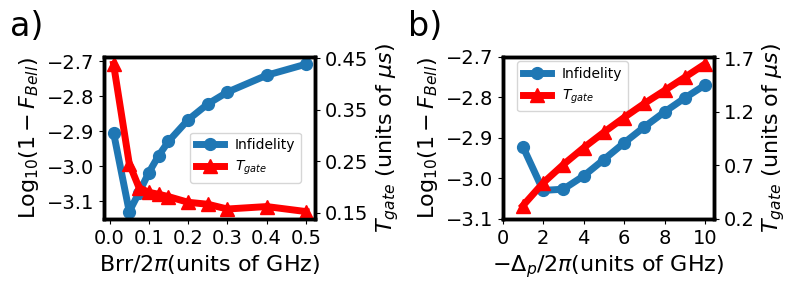

In [15]:
fig, axs = plt.subplots(1,2)

axa = axs[0]
axb = axs[1]
# axc = axs[1,0]
# axd = axs[1,1]
# times = np.linspace(0.0, T_gate, 100)

#axa
axap = axa.plot(brr, np.log10(brr_op_fidelity), '-o', markersize=8.5, linewidth=5, label="Infidelity")
# axap2 = axa.plot(brr, np.log10(brr_op_fidelity_r2), '-o', markersize=8, linewidth=5, label="Infidelity-r2")
axat = axa.twinx()
axatp = axat.plot(brr, brr_op_tgate, '-^', markersize=10, linewidth=5, label=r"$T_{gate}$", color='r')
# axald = axap + axap2 + axatp
axald = axap + axatp
axalb = [lb.get_label() for lb in axald]
axa.legend(axald, axalb, bbox_to_anchor=(.375, .575), fontsize=10)
# axa.legend(axald, axalb, fontsize=10)

axa.set_xlabel('Brr' '$/ 2 \pi$' '(units of GHz)', fontsize=16)
axa.set_ylabel('Log' r'$_{10}$' r'$(1-F_{Bell})$', fontsize=16)
axat.set_ylabel(r'$T_{gate}$' ' (units of ' r'$\mu s$' ')', fontsize=16)

# xinterval = np.arange(0, 1.52, 0.5)
xinterval = np.arange(0, 0.52, 0.1)
y1interval = np.arange(-3.1, -2.6, 0.1)
y2interval = np.arange(0.15, 0.52, 0.1)
axa.set_xticks(xinterval)
axa.set_yticks(y1interval)
axat.set_yticks(y2interval)
axa.tick_params(axis='x', labelsize=14)
axa.tick_params(axis='y', labelsize=14)
axat.tick_params(axis='y', labelsize=14)

axa.set_title('a)', x=-0.365, pad=15, fontsize=24)

#axb
axbp = axb.plot(deltaamp, np.log10(delta_op_fidelity), '-o', markersize=8.5, linewidth=5, label="Infidelity")
# axbp2 = axb.plot(deltaamp, np.log10(delta_op_fidelity_r2), '-o', markersize=8, linewidth=5, label="Infidelity-r2")
axbt = axb.twinx()
axbtp = axbt.plot(deltaamp, delta_op_tgate, '-^', markersize=10, linewidth=5, label=r"$T_{gate}$", color='r')
# axbld = axbp + axbp2 + axbtp
axbld = axbp + axbtp
axblb = [lb.get_label() for lb in axbld]
axb.legend(axbld, axblb, bbox_to_anchor=(.625, .62), fontsize=10)

axb.set_xlabel(r'$-\Delta_{p} / 2 \pi$' '(units of GHz)', fontsize=16)
axb.set_ylabel('Log' r'$_{10}$' r'$(1-F_{Bell})$', fontsize=16)
axbt.set_ylabel(r'$T_{gate}$' ' (units of ' r'$\mu s$' ')', fontsize=16)

xinterval = np.arange(0, 11, 2)
y1interval = np.arange(-3.1, -2.6, 0.1)
y2interval = np.arange(0.2, 1.8, 0.5)
axb.set_xticks(xinterval)
axb.set_yticks(y1interval)
axbt.set_yticks(y2interval)
axb.tick_params(axis='x', labelsize=14)
axb.tick_params(axis='y', labelsize=14)
axbt.tick_params(axis='y', labelsize=14)

axb.set_title('b)', x=-0.365, pad=15, fontsize=24)

plt.savefig('fig2.eps', dpi=1200)